In [22]:
from pymongo import MongoClient
import pandas as pd

# Connexion au conteneur Mongo Docker
client = MongoClient("mongodb://localhost:27017/")

# 📂 Remplace ici par ton app_id si nécessaire
app_id = 1672500
collection = client["steamdb"][f"reviews_{app_id}"]


In [23]:
# Chargement des documents Mongo dans un DataFrame
cursor = collection.find()
df = pd.DataFrame(list(cursor))

print(f"✅ {len(df)} avis chargés depuis reviews_{app_id}")
df[["review", "voted_up", "language"]].head()


✅ 3756 avis chargés depuis reviews_1672500


,review,voted_up,language
0,very good game,True,tchinese
1,sehr gut da ich gundam auch als modelle baue i...,True,german
2,This game is not perfect but I very much enjoy...,True,english
3,I have a love hate relationship with this game...,False,english
4,yeah nice,True,english


In [24]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "", text)              # liens
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", "", text)        # ponctuation
    text = re.sub(r"\s+", " ", text).strip()          # espaces multiples
    return text

df["cleaned_review"] = df["review"].apply(clean_text)
df["cleaned_review"].head()


0                                       very good game
1    sehr gut da ich gundam auch als modelle baue i...
2    this game is not perfect but i very much enjoy...
3    i have a love hate relationship with this game...
4                                            yeah nice
Name: cleaned_review, dtype: object

<Axes: title={'center': 'Votes'}, ylabel='proportion'>

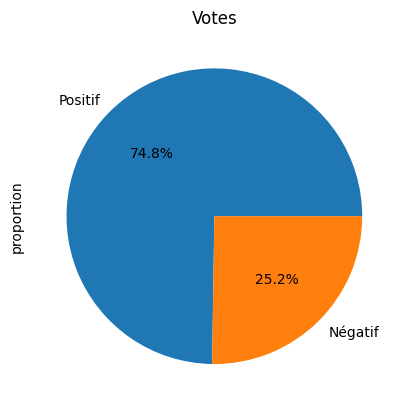

In [25]:
# Répartition des votes
df["voted_up"].value_counts(normalize=True).plot.pie(autopct='%1.1f%%', labels=["Positif", "Négatif"], title="Votes")


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Limite à 2000 reviews pour aller vite
sample = df["cleaned_review"].dropna().sample(min(2000, len(df)))

vectorizer = TfidfVectorizer(max_df=0.8, min_df=5, stop_words='english')
X = vectorizer.fit_transform(sample)

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)

sample_df = pd.DataFrame({"review": sample, "cluster": clusters})
sample_df.head()


,review,cluster
495,str fire if your a gundam head,3
960,mghgmghgmg,0
2322,,0
3668,hold shift to use op skill is so aggravating w...,3
1583,pspsvpspc,0


In [27]:
for i in range(5):
    print(f"\n🔹 Cluster {i} :\n")
    print(sample_df[sample_df["cluster"] == i]["review"].head(3).to_string(index=False))




🔹 Cluster 0 :

mghgmghgmg
          
 pspsvpspc

🔹 Cluster 1 :

                             ex aaaaexaaa trans am
gundam harute yay no marute mode sad please giv...
opex exop ex bossboss boss dlc ex ex ex ex opex...

🔹 Cluster 2 :

finally a good gundam game in pc
                            good
                            good

🔹 Cluster 3 :

                    str fire if your a gundam head
hold shift to use op skill is so aggravating wh...
     its literally the gundam game weve all wanted

🔹 Cluster 4 :

dynasty warriors meets monster hunter with a gu...


In [28]:
from textblob import TextBlob

df["sentiment"] = df["cleaned_review"].apply(lambda x: TextBlob(x).sentiment.polarity)
df["sentiment_label"] = df["sentiment"].apply(lambda s: "pos" if s > 0 else ("neg" if s < 0 else "neu"))
df["sentiment_label"].value_counts()


sentiment_label
neu    1852
pos    1437
neg     467
Name: count, dtype: int64

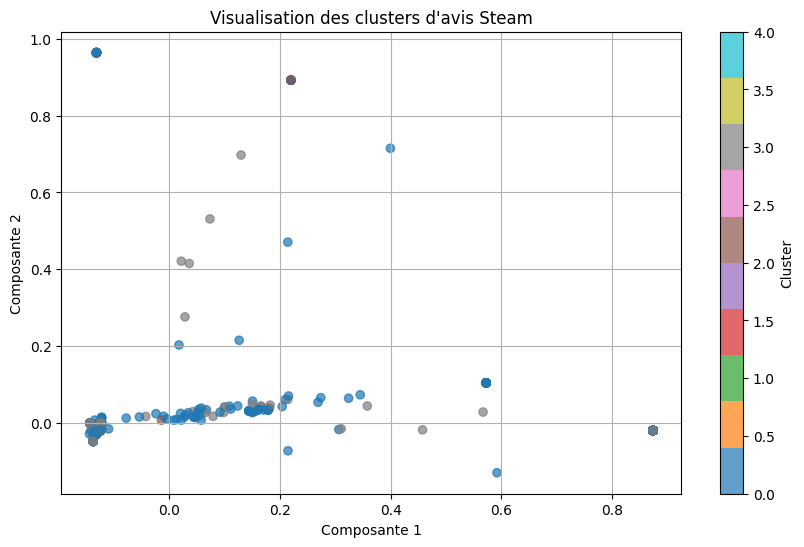

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='tab10', alpha=0.7)
plt.title("Visualisation des clusters d'avis Steam")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()


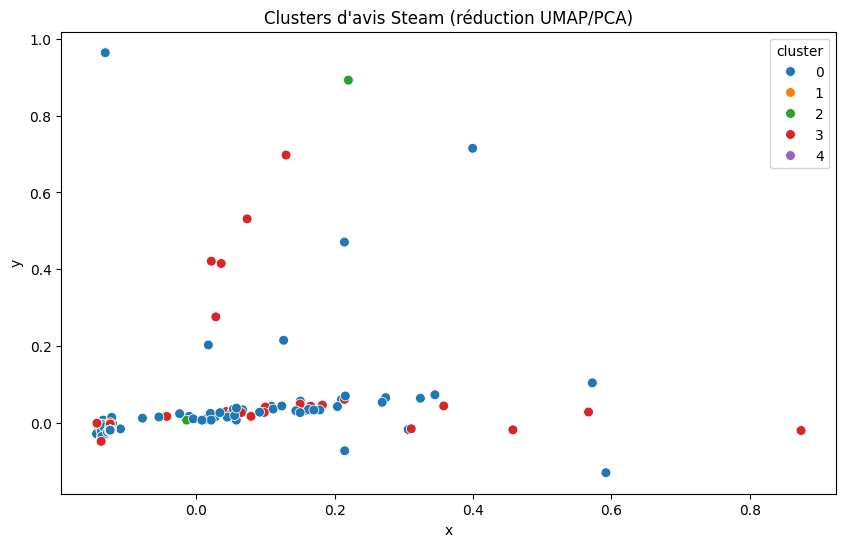

In [30]:
import seaborn as sns
import pandas as pd

plot_df = pd.DataFrame(X_reduced, columns=["x", "y"])
plot_df["cluster"] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="x", y="y", hue="cluster", palette="tab10", s=50)
plt.title("Clusters d'avis Steam (réduction UMAP/PCA)")
plt.show()
